In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
from scipy.signal import savgol_filter
from dotenv import load_dotenv

from rfml_uav.drone_rf.consts import BUI, BUI_dict, M, FS

load_dotenv()

True

In [ ]:
# File path setup
filepath = os.path.join(os.getenv("DATA_PATH"), "PSD", "mat") 

# Parameters
opt = 2  # Change to 1, 2, or 3 to alternate between the 1st, 2nd, and 3rd DNN inputs respectively

f = 2400 + np.arange(0, FS, FS/M)  # Frequency array for plotting
S = 10  # Number of points in the moving average filter for smoothing
c = np.array([[0, 0, 1], [1, 0, 0], [0, 1, 0], [0, 0, 0.1724], [1, 0.1034, 0.7241], 
              [1, 0.8276, 0], [0, 0.3448, 0], [0.5172, 0.5172, 1], [0.6207, 0.3103, 0.2759], 
              [0, 1, 0.7586]])  # 10 distinct colours for plotting

In [14]:
# Averaging spectra
s = np.zeros((len(BUI), M))
for i, bui in enumerate(BUI):
    data = scipy.io.loadmat(os.path.join(filepath, bui + '.mat'))['Data']
    s[i, :] = np.mean(data, axis=1)


# Aggregating and smoothing RF spectra
match opt:
    case 1:
        sig = np.zeros((2, M))
        sig_smooth = np.zeros((2, M))
        sig[0, :] = s[0, :]
        sig[1, :] = np.mean(s[1:, :], axis=0)
        sig_smooth = savgol_filter(sig, S, 1)
    case 2:
        sig = np.zeros((4, M))
        sig_smooth = np.zeros((4, M))
        sig[0, :] = s[0, :]
        sig[1, :] = np.mean(s[1:5, :], axis=0)
        sig[2, :] = np.mean(s[5:9, :], axis=0)
        sig[3, :] = s[9, :]
        sig_smooth = savgol_filter(sig, S, 1)
    case 3:
        sig = s
        sig_smooth = np.zeros((10, M))
        sig_smooth = savgol_filter(sig, S, 1)

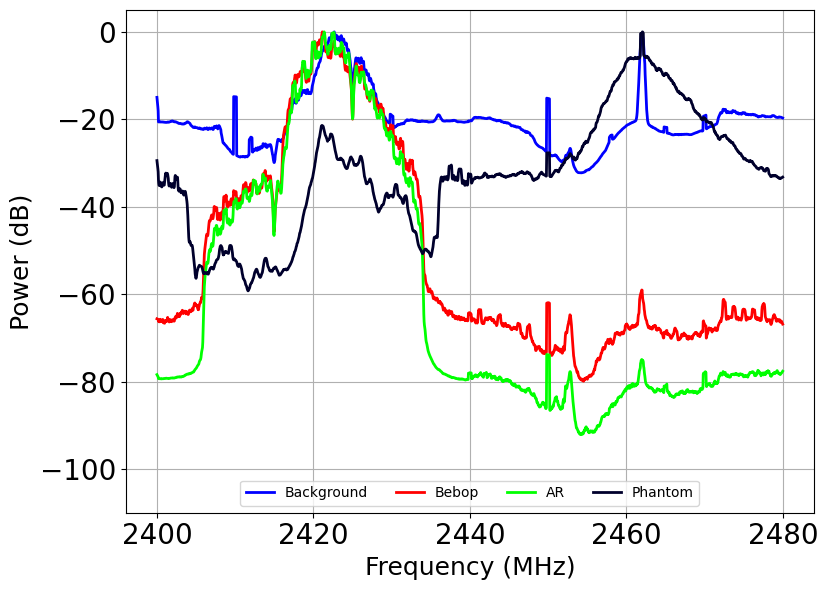

In [15]:
# Plotting the RF spectra
plt.figure(figsize=(8.4, 6))
a = []
for i in range(sig.shape[0]):
    a.append(plt.plot(f, 20 * np.log10(sig_smooth[i, :] / np.max(sig_smooth[i, :])), 
                     color=c[i, :], linewidth=2)[0])

plt.xlabel('Frequency (MHz)', fontsize=18)
plt.ylabel('Power (dB)', fontsize=18)
plt.ylim([-110, 5])
if opt == 3:
    plt.legend(a, [f'Class {i+1}' for i in range(sig.shape[0])], loc='lower center', ncol=5)
elif opt == 2:
    plt.legend(a, [drone_type for drone_type in BUI_dict.keys()], loc='lower center', ncol=5)
else:
    plt.legend(a, [f'Class {i+1}' for i in range(sig.shape[0])], loc='lower center')

plt.grid(True, which='both')
plt.gca().tick_params(axis='both', labelsize=20)
plt.gca().set_facecolor('w')
plt.tight_layout()

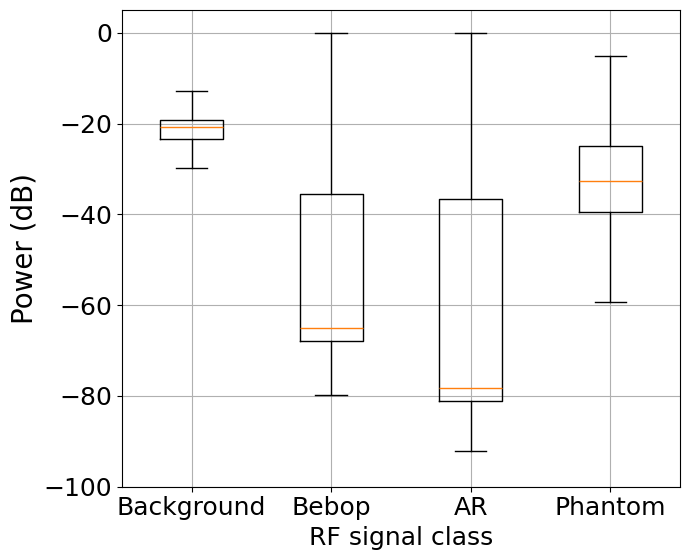

In [18]:
# Boxplot
plt.figure(figsize=(7, 5.7))
plt.boxplot(20 * np.log10(sig_smooth / np.max(sig_smooth, axis=1, keepdims=True)).T, showfliers=False, whiskerprops={'linewidth': 1})
plt.xlabel('RF signal class', fontsize=18)
plt.xticks([1, 2, 3, 4], BUI_dict.keys())
plt.ylabel('Power (dB)', fontsize=20)
plt.ylim([-100, 5])
plt.grid(True, which='both')
plt.gca().tick_params(axis='both', labelsize=18)
plt.gca().set_facecolor('w')
plt.tight_layout()

In [ ]:
save_filepath = os.path.join(os.getenv("DATA_PATH"), "analysis")
os.makedirs(save_filepath, exist_ok=True)

# Saving option
Q = input('Do you want to save the results (Y/N): ')
if Q.lower() == 'y':
    plt.figure(1)
    plt.savefig(os.path.join(save_filepath, f'Spectrum_{opt}.pdf'), dpi=512, format='pdf')
    plt.figure(2)
    plt.savefig(os.path.join(save_filepath, f'Box_{opt}.pdf'), dpi=512, format='pdf')